In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
from pathlib import Path

# Main folders
input_folder = Path("../images/dataset")
outputs_folder = Path("../outputs")
charts_folder = Path("../charts")

# Output folders
detected_min5_folder = outputs_folder / "detected_images_min5"
detected_min7_folder = outputs_folder / "detected_images_min7"
success_folder = outputs_folder / "success_examples"
failure_folder = outputs_folder / "failure_examples"
multiple_folder = outputs_folder / "multiple_detection_examples"
archive_folder = outputs_folder / "archive_loose_outputs"

# Create folders if they do not exist
for folder in [
    outputs_folder,
    charts_folder,
    detected_min5_folder,
    detected_min7_folder,
    success_folder,
    failure_folder,
    multiple_folder,
    archive_folder
]:
    folder.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")


## 1. Load image files

In [3]:
image_files = sorted([
    file for file in os.listdir(input_folder)
    if file.lower().endswith(IMAGE_EXTENSIONS)
])

print("Number of images found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError("No images found. Check that your dataset is inside ../images/dataset/")


Number of images found: 1800


## 2. Display one sample image

In [4]:
sample_image_path = input_folder / image_files[0]

image = cv2.imread(str(sample_image_path))

if image is None:
    raise ValueError(f"Could not read image: {sample_image_path}")

print("Sample image:", sample_image_path.name)
print("Image type:", type(image))
print("Image shape:", image.shape)


Sample image: 001_08194468.jpg
Image type: <class 'numpy.ndarray'>
Image shape: (474, 474, 3)


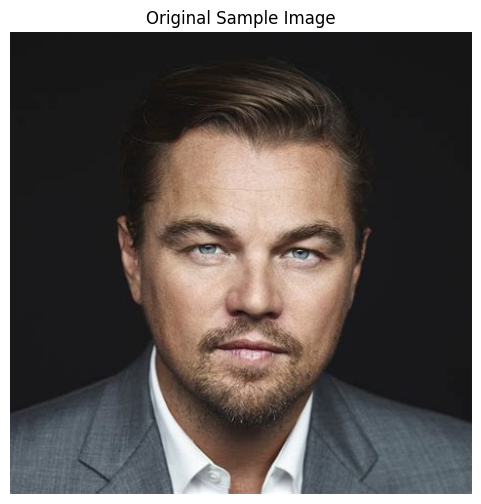

In [5]:
# OpenCV loads images in BGR format.
# Matplotlib expects RGB format, so we convert before displaying.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Original Sample Image")
plt.axis("off")
plt.show()


## 3. Convert images into grayscale

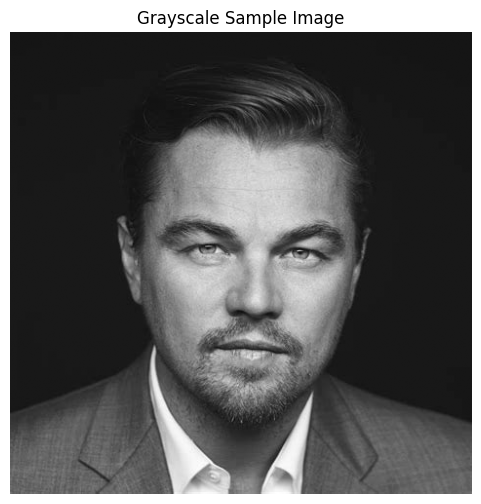

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Sample Image")
plt.axis("off")
plt.show()


## 4. Load Haar Cascade Face detector

In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise ValueError("Haar Cascade XML file was not loaded correctly.")

print("Haar Cascade face detector loaded successfully.")


Haar Cascade face detector loaded successfully.


## 5. Test detector on one image

In [8]:
FINAL_MIN_NEIGHBORS = 7

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=FINAL_MIN_NEIGHBORS,
    minSize=(30, 30)
)

print(f"Number of faces detected: {len(faces)}")
print(faces)


Number of faces detected: 1
[[124 120 257 257]]


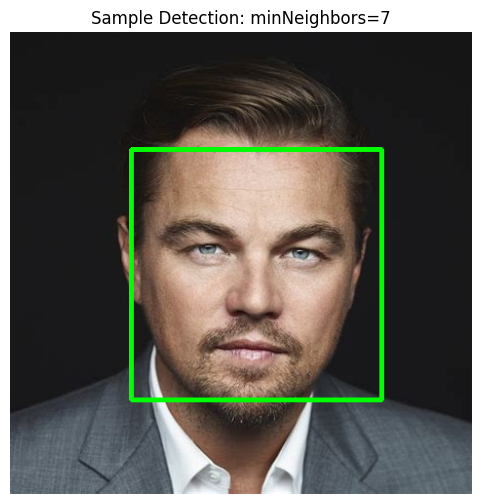

In [9]:
sample_output = image_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(
        sample_output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

plt.figure(figsize=(6, 6))
plt.imshow(sample_output)
plt.title(f"Sample Detection: minNeighbors={FINAL_MIN_NEIGHBORS}")
plt.axis("off")
plt.show()


In [10]:
sample_output_path = outputs_folder / "sample_face_detection.jpg"

# Convert RGB back to BGR before saving with OpenCV.
sample_output_bgr = cv2.cvtColor(sample_output, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(sample_output_path), sample_output_bgr)

print(f"Saved sample output to: {sample_output_path}")


Saved sample output to: ..\outputs\sample_face_detection.jpg


## 6. Create resuable batch detection function

In [11]:
def clear_image_files(folder):
    """Remove old image files from a folder so reruns do not mix old and new outputs."""
    folder.mkdir(parents=True, exist_ok=True)

    for file_path in folder.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
            file_path.unlink()


def run_face_detection(min_neighbors, output_folder_name):
    """Run Haar Cascade face detection on all images and save boxed outputs."""
    output_folder = outputs_folder / output_folder_name
    output_folder.mkdir(parents=True, exist_ok=True)

    # Clear old image outputs from this folder before rerunning.
    clear_image_files(output_folder)

    detection_results = []

    for file in image_files:
        image_path = input_folder / file
        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Could not read: {file}")
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=min_neighbors,
            minSize=(30, 30)
        )

        output_image = image.copy()

        for (x, y, w, h) in faces:
            cv2.rectangle(
                output_image,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                3
            )

        output_path = output_folder / file
        cv2.imwrite(str(output_path), output_image)

        detection_results.append({
            "filename": file,
            "faces_detected": len(faces),
            "min_neighbors": min_neighbors
        })

    return pd.DataFrame(detection_results)


## 7. Comparing parameters 5 and 7 minNeighbors

In [12]:
results_5 = run_face_detection(
    min_neighbors=5,
    output_folder_name="detected_images_min5"
)

results_7 = run_face_detection(
    min_neighbors=7,
    output_folder_name="detected_images_min7"
)

print("minNeighbors=5 images processed:", len(results_5))
print("minNeighbors=7 images processed:", len(results_7))


minNeighbors=5 images processed: 1800
minNeighbors=7 images processed: 1800


In [13]:
def summarize_results(results_df, label):
    total_images = len(results_df)
    images_with_faces = (results_df["faces_detected"] > 0).sum()
    images_without_faces = (results_df["faces_detected"] == 0).sum()
    images_with_multiple_faces = (results_df["faces_detected"] >= 2).sum()
    detection_rate = images_with_faces / total_images

    return {
        "Setting": label,
        "Total Images": total_images,
        "Images with Faces": images_with_faces,
        "Images with No Faces": images_without_faces,
        "Images with Multiple Detections": images_with_multiple_faces,
        "Detection Rate": round(detection_rate, 4)
    }


comparison_df = pd.DataFrame([
    summarize_results(results_5, "minNeighbors=5"),
    summarize_results(results_7, "minNeighbors=7")
])

comparison_df


,Setting,Total Images,Images with Faces,Images with No Faces,Images with Multiple Detections,Detection Rate
0,minNeighbors=5,1800,1728,72,264,0.9600
1,minNeighbors=7,1800,1711,89,174,0.9506


In [14]:
comparison_df.to_csv(outputs_folder / "parameter_comparison.csv", index=False)
print("Saved parameter comparison to outputs/parameter_comparison.csv")


Saved parameter comparison to outputs/parameter_comparison.csv


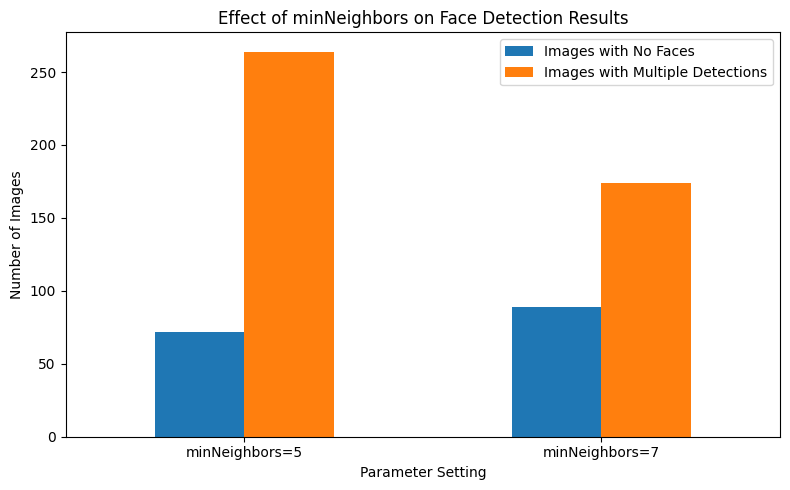

In [15]:
comparison_df.plot(
    x="Setting",
    y=["Images with No Faces", "Images with Multiple Detections"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Effect of minNeighbors on Face Detection Results")
plt.xlabel("Parameter Setting")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(charts_folder / "minneighbors_comparison.png")
plt.show()


### Parameter Tuning Findings

Two `minNeighbors` settings were tested to compare the trade-off between missed detections and multiple detections.

With `minNeighbors=5`, the detector achieved a detection rate of 96.00%, with 72 images having no detected faces. However, 264 images had multiple detections, which visual inspection showed could include false positives.

With `minNeighbors=7`, the detection rate decreased slightly to 95.06%, with 89 images having no detected faces. However, the number of images with multiple detections decreased from 264 to 174. This suggests that the stricter setting helped reduce likely false positives while maintaining a high overall detection rate.

The final setting selected was `minNeighbors=7`, as it provided a better balance between detection coverage and reducing excessive false positive detections.


In [16]:
final_results_df = results_7.copy()

final_results_df.to_csv(outputs_folder / "face_detection_results.csv", index=False)

final_results_df.head()


,filename,faces_detected,min_neighbors
0,001_08194468.jpg,1,7
1,001_08212dcd.jpg,1,7
2,001_21a7d5e6.jpg,1,7
3,001_2288a4f6.jpg,1,7
4,001_504d320d.jpg,1,7


In [17]:
total_images = len(final_results_df)
images_with_faces = (final_results_df["faces_detected"] > 0).sum()
images_without_faces = (final_results_df["faces_detected"] == 0).sum()
images_with_multiple_faces = (final_results_df["faces_detected"] >= 2).sum()
detection_rate = images_with_faces / total_images

final_summary_df = pd.DataFrame({
    "Metric": [
        "Total images processed",
        "Images with at least one detected face",
        "Images with no detected faces",
        "Images with multiple detections",
        "Detection rate"
    ],
    "Value": [
        total_images,
        images_with_faces,
        images_without_faces,
        images_with_multiple_faces,
        round(detection_rate, 4)
    ]
})

final_summary_df


,Metric,Value
0,Total images processed,1800.0000
1,Images with at least one detected face,1711.0000
2,Images with no detected faces,89.0000
3,Images with multiple detections,174.0000
4,Detection rate,0.9506


In [18]:
final_summary_df.to_csv(outputs_folder / "face_detection_summary.csv", index=False)
print("Saved final summary to outputs/face_detection_summary.csv")


Saved final summary to outputs/face_detection_summary.csv


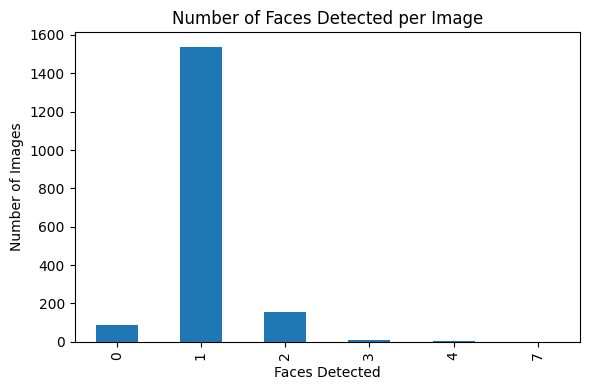

In [19]:
plt.figure(figsize=(6, 4))
final_results_df["faces_detected"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Faces Detected per Image")
plt.xlabel("Faces Detected")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(charts_folder / "faces_detected_distribution_final.png")
plt.show()


### Final Detection Results Summary

The final detector setting used `minNeighbors=7`.

The detector processed 1,800 images and detected at least one face in 1,711 images, giving a detection rate of 95.06%. It produced no detections in 89 images and multiple detections in 174 images.

This detection rate should not be interpreted as true model accuracy because the dataset does not contain manually labelled face bounding boxes. Instead, it measures how often the detector produced at least one face-like region per image.


## 8. Qualitatve error analysis

In [20]:
def show_detection_examples(results_df, output_folder_name, face_count, n=6):
    """Display sample detected images for a given number of detected faces."""
    subset = results_df[results_df["faces_detected"] == face_count]

    if len(subset) == 0:
        print(f"No images found with {face_count} faces detected.")
        return

    sample_df = subset.sample(min(n, len(subset)), random_state=42)

    plt.figure(figsize=(12, 8))

    for i, row in enumerate(sample_df.itertuples(), 1):
        image_path = outputs_folder / output_folder_name / row.filename
        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Could not read: {image_path}")
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i)
        plt.imshow(image_rgb)
        plt.title(f"Faces detected: {row.faces_detected}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


### Images with 0 Faces Detected

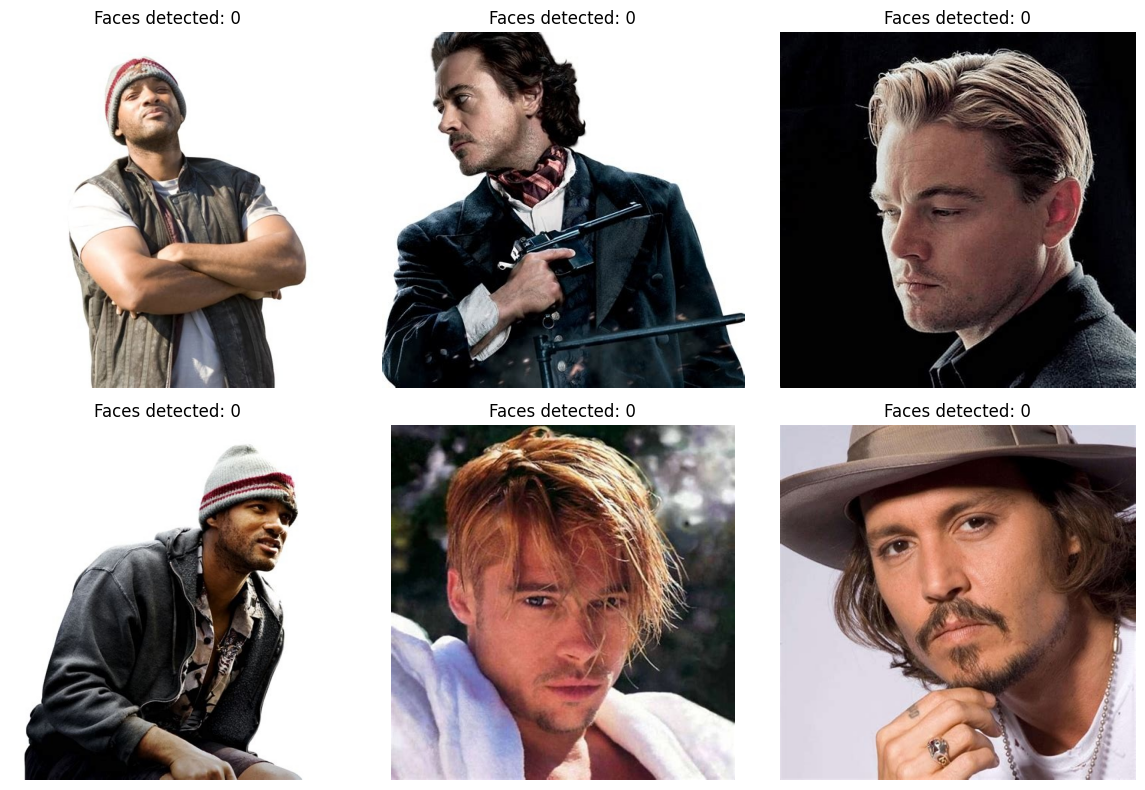

In [21]:
show_detection_examples(final_results_df, "detected_images_min7", 0)


Several zero-detection examples still contained visible faces. This suggests that Haar Cascade struggled with non-frontal poses, facial accessories, tilted faces, shadows, and smaller faces in full-body images.


### Images with 1 Face Detected

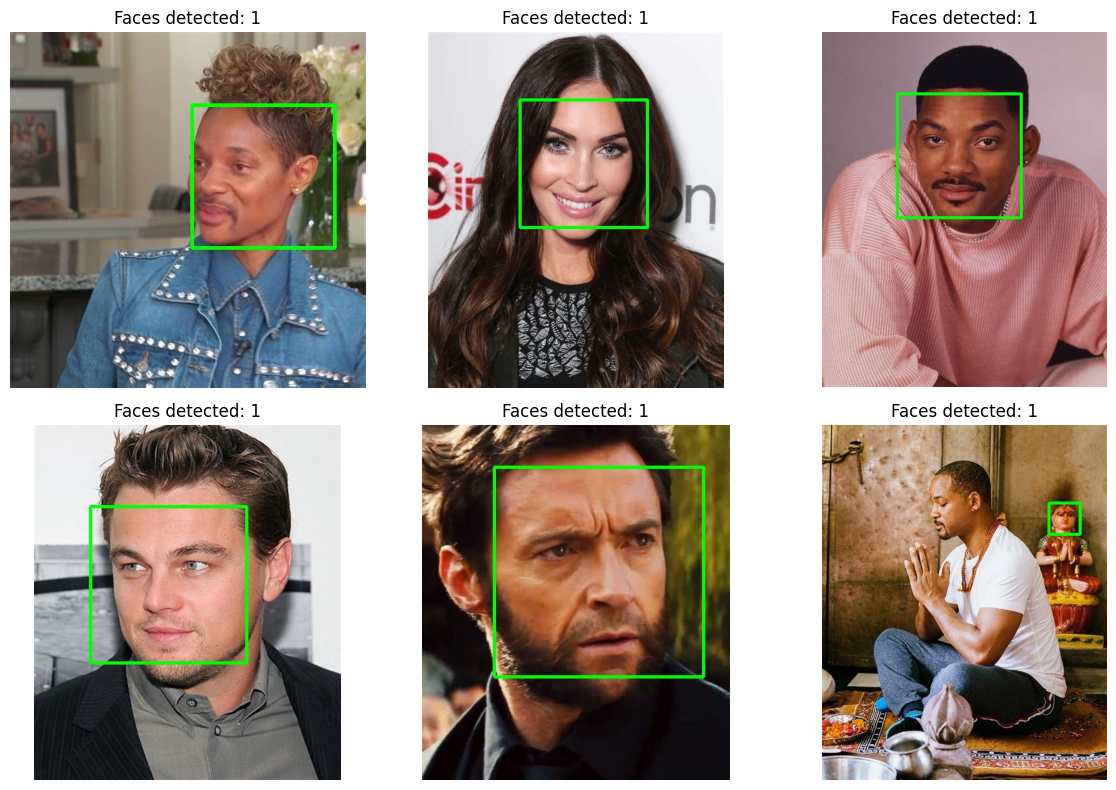

In [22]:
show_detection_examples(final_results_df, "detected_images_min7", 1)


Images with one detected face were generally successful, especially when the face was front-facing, large, and well-lit. However, detection count alone does not fully measure detection quality because some boxes may still be poorly localised.


### Images with 2 Faces Detected

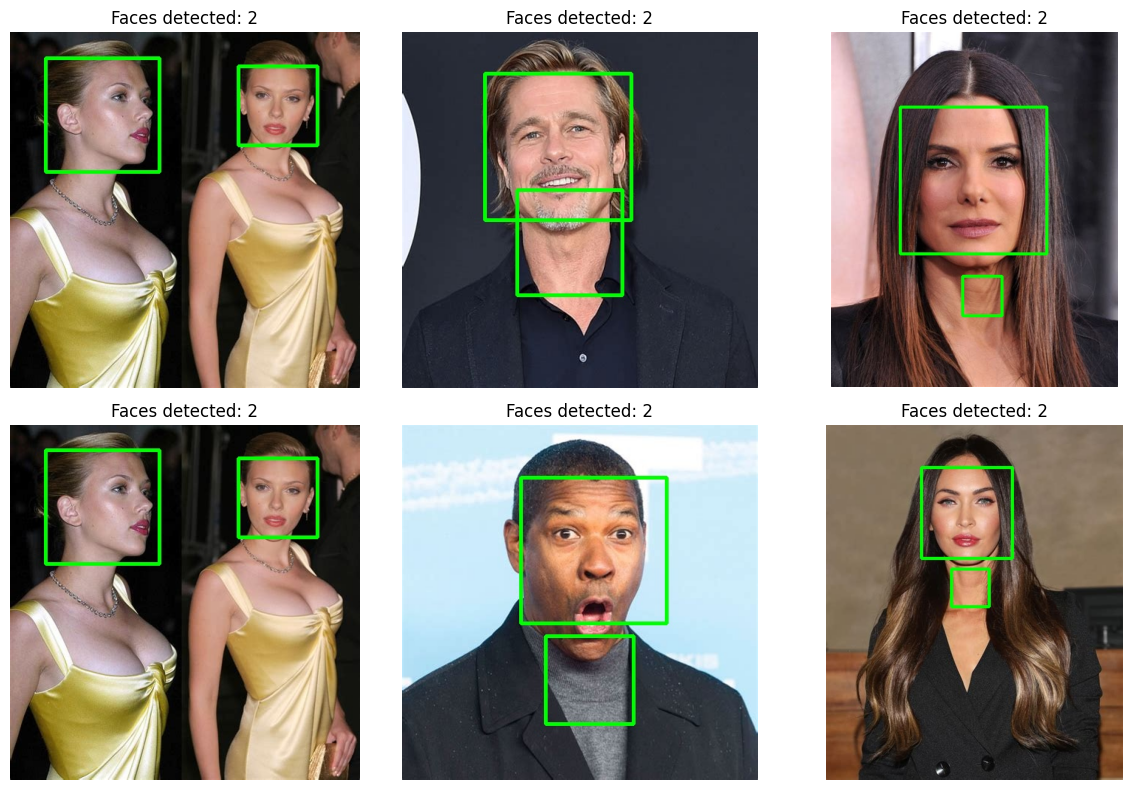

In [23]:
show_detection_examples(final_results_df, "detected_images_min7", 2)


### Images with 3 Faces Detected

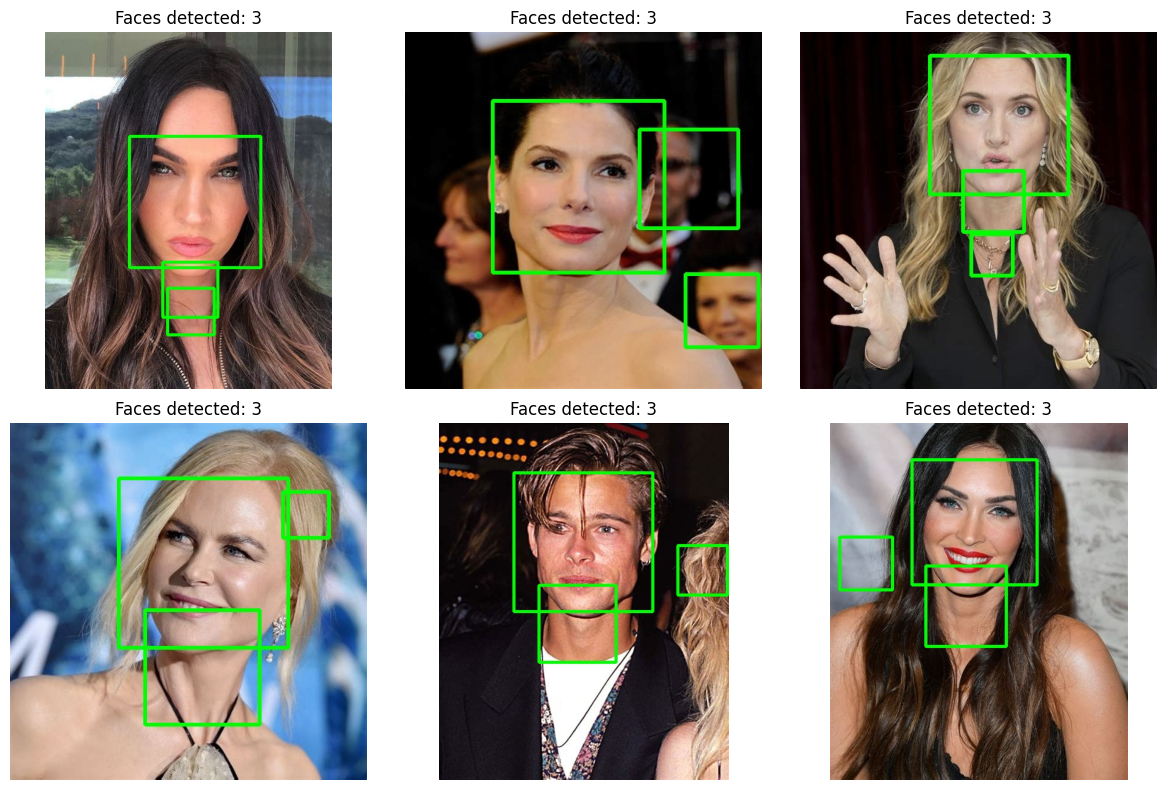

In [24]:
show_detection_examples(final_results_df, "detected_images_min7", 3)


Images with multiple detections often included false positives. In some cases, the detector correctly found the main face but also detected background regions, accessories, clothing, or other face-like patterns as additional faces.


## 9. Saving selected images for examples

In [25]:
def clear_all_files(folder):
    """Clear all files from an example folder before copying fresh examples."""
    folder.mkdir(parents=True, exist_ok=True)

    for file_path in folder.iterdir():
        if file_path.is_file():
            file_path.unlink()


# Clear old example folders so examples match the final minNeighbors=7 setting.
for folder in [success_folder, failure_folder, multiple_folder]:
    clear_all_files(folder)


final_output_folder = detected_min7_folder

# Success examples with exactly 1 detected face
success_samples = final_results_df[final_results_df["faces_detected"] == 1].sample(
    6,
    random_state=42
)

for row in success_samples.itertuples():
    source = final_output_folder / row.filename
    destination = success_folder / row.filename

    if source.exists():
        shutil.copy(str(source), str(destination))


# Failure examples with 0 detected faces
failure_subset = final_results_df[final_results_df["faces_detected"] == 0]

failure_samples = failure_subset.sample(
    min(6, len(failure_subset)),
    random_state=42
)

for row in failure_samples.itertuples():
    source = final_output_folder / row.filename
    destination = failure_folder / row.filename

    if source.exists():
        shutil.copy(str(source), str(destination))


# Multiple detection examples witt 2 or more detections
multiple_subset = final_results_df[final_results_df["faces_detected"] >= 2]

multiple_samples = multiple_subset.sample(
    min(6, len(multiple_subset)),
    random_state=42
)

for row in multiple_samples.itertuples():
    source = final_output_folder / row.filename
    destination = multiple_folder / row.filename

    if source.exists():
        shutil.copy(str(source), str(destination))
